This Code Cell Mounts the user's Google Drive, so that the code in this notebook can access the Google Drive as storage.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This Code cell reads the data from the file:  wind_turbines.csv and stores it as a collection of records (rows), in a pandas data_frame data structure.  It then groups the data by state (collecting together all of the rows with the same state in the first column), and sums up the values from the 10th column, Number_Turbines, for each state.  It then sorts the data in decending order by Number_Of_turbines in each state.

In [ ]:
# read a .csv file called wind_turbines.csv.  Each line of the file represents a wind turbine farm.
# The first column, Site.State,  is state name where the wind farm is located.
# The 10th column, Project.Number_Turbines is the number of turbines on that farm.

import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file into a pandas DataFrame
try:
  data_frame = pd.read_csv('/content/drive/My Drive/Classroom/IB_AP Comp Sci/Java Projects/Wind_Turbines/wind_turbines.csv')
except FileNotFoundError:
  print("Error: 'wind_turbines.csv' not found. Please upload the file to your Colab environment.")
  exit()


# Group by State.  For each group, get the collection of Number_Turbines for that group, and get the sum of each collection.
# Store this as a dataframe of state/number_of_turbine pairs in state_turbine_counts
state_turbine_counts = data_frame.groupby('Site.State')['Project.Number_Turbines'].sum()


# Sort the states by the number of turbines in descending order
sorted_states = state_turbine_counts.sort_values(ascending=False)



This code cell simply prints the resulting data_frame, sorted_states, showing the number of turbines in each state.

In [ ]:
print(sorted_states)

Site.State
TX    1712713
CA     545180
IA     533905
CO     404018
KS     392136
OK     387577
IL     305057
WA     241890
OR     220753
MN     208032
IN     168419
NM     168119
ND     136742
NE     104982
MO     102529
SD      81484
WY      80519
MI      71533
NY      71004
MT      49836
PA      32255
OH      32177
WI      29418
WV      22556
AZ      21831
ID      21595
UT      14847
ME      12336
NC      10816
NV       4356
HI       2253
PR       2114
NH       1916
MD       1585
VT       1064
AK        857
MA        560
TN        234
RI         70
NJ         26
CT          4
VA          3
DE          1
GU          1
Name: Project.Number_Turbines, dtype: int64


This code cell simply builds a bar graph of that same data with State on the x-axis and number of turbines on the y-axis

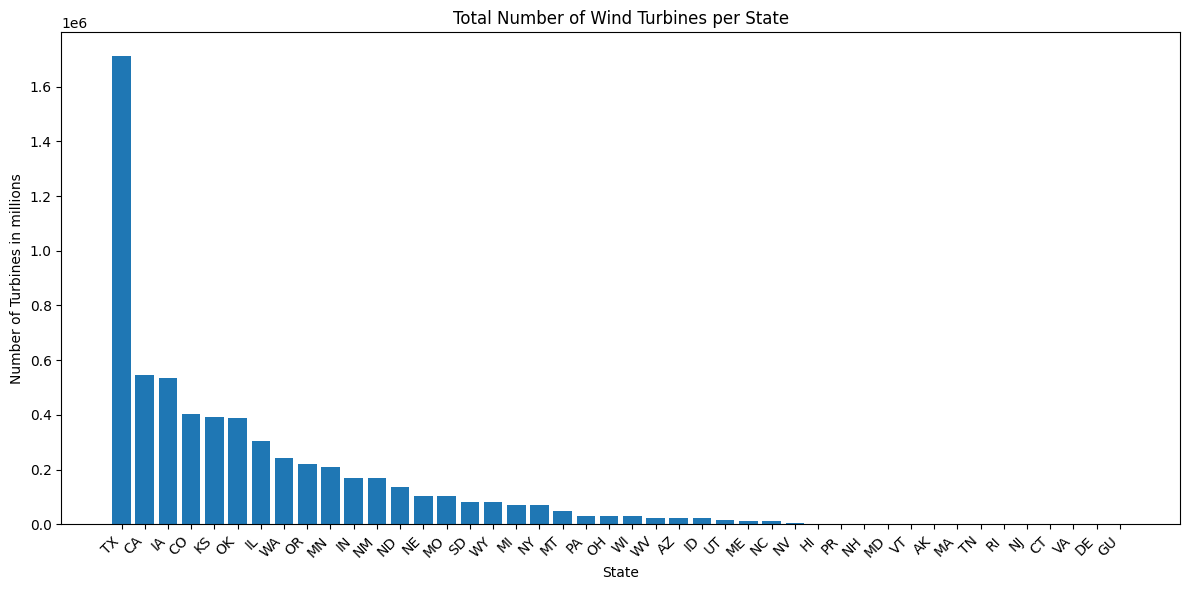

In [ ]:
# Create the bar graph
plt.figure(figsize=(12, 6))  # Adjust figure size
plt.bar(sorted_states.index, sorted_states.values)
plt.xlabel('State')
plt.ylabel('Number of Turbines in millions')
plt.title('Total Number of Wind Turbines per State')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout() # prevents labels from overlapping
plt.show()
